# Movie recommender demo

Pick a MovieLens user, see the top 10 movies from two methods, and read the reason for each pick.

- **Content-based**: movies whose genres and decade match movies the user liked (`src/explain_content.py`).
- **Matrix factorization**: movies the learned model predicts the user will rate highest (`src/explain_mf.py`).

Set `USER_ID` in section 2 and run from there. The matrix factorization model is cached in `data/mf_model.pkl` and trained on the first run (about 45 seconds).

## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(str(Path.cwd().parent / "src"))

import demo
from explain_content import ratings, recommend
from explain_mf import explain_mf, n_ratings, recommend_mf, score_parts, title_of

pd.set_option("display.max_colwidth", None)

Load the saved model, or train it if there is none.

In [2]:
model = demo.load_model(refit=False)
print("users:", len(model["user_index"]), " movies:", len(model["movie_index"]), " hidden numbers per user/movie:", model["P"].shape[1])

users: 610  movies: 9724  hidden numbers per user/movie: 20


## 2. Pick a user

Change `USER_ID` (1 to 610) and re-run from here.

In [3]:
USER_ID = 3

mine = ratings[ratings["userId"] == USER_ID].assign(title=lambda d: d["movieId"].map(title_of))
print(f"User {USER_ID}: {len(mine)} ratings, average {mine['rating'].mean():.2f}")
mine.sort_values("rating", ascending=False).head(10)[["title", "rating"]]

User 3: 39 ratings, average 2.44


,title,rating
266,Escape from L.A. (1996),5.0
290,Galaxy of Terror (Quest) (1981),5.0
289,Hangar 18 (1980),5.0
296,Death Race 2000 (1975),5.0
298,Troll 2 (1990),5.0
294,Alien Contamination (1980),5.0
282,Saturn 3 (1980),5.0
292,Android (1982),5.0
285,"Road Warrior, The (Mad Max 2) (1981)",5.0
287,The Lair of the White Worm (1988),5.0


How does this user spread their ratings? Compare it with the all-user average of 3.50.

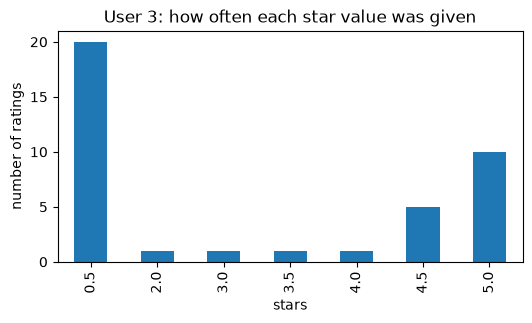

In [4]:
mine["rating"].value_counts().sort_index().plot.bar(figsize=(6, 3))
plt.xlabel("stars")
plt.ylabel("number of ratings")
plt.title(f"User {USER_ID}: how often each star value was given")
plt.show()

## 3. Content-based top 10

Each reason names the liked movie that is closest and lists what the two movies share.

In [5]:
content = recommend(USER_ID, n=10)
content

,title,score,why
0,Jurassic Park (1993),1.0,"Shares genres Action, Adventure, Sci-Fi and Thriller and the 1990s decade with Escape from L.A. (1996), which you rated 5.0."
1,Independence Day (a.k.a. ID4) (1996),1.0,"Shares genres Action, Adventure, Sci-Fi and Thriller and the 1990s decade with Escape from L.A. (1996), which you rated 5.0."
2,Alien (1979),1.0,"Shares genres Horror and Sci-Fi and the 1970s decade with Piranha (1978), which you rated 4.5."
3,"Terminator, The (1984)",1.0,"Shares genres Action, Sci-Fi and Thriller and the 1980s decade with Hangar 18 (1980), which you rated 5.0."
4,Blade Runner (1982),1.0,"Shares genres Action, Sci-Fi and Thriller and the 1980s decade with Hangar 18 (1980), which you rated 5.0."
5,Indiana Jones and the Temple of Doom (1984),1.0,"Shares genres Action, Adventure and Fantasy and the 1980s decade with Conan the Barbarian (1982), which you rated 4.5."
6,Star Trek: First Contact (1996),1.0,"Shares genres Action, Adventure, Sci-Fi and Thriller and the 1990s decade with Escape from L.A. (1996), which you rated 5.0."
7,Total Recall (1990),1.0,"Shares genres Action, Adventure, Sci-Fi and Thriller and the 1990s decade with Escape from L.A. (1996), which you rated 5.0."
8,"Lost World: Jurassic Park, The (1997)",1.0,"Shares genres Action, Adventure, Sci-Fi and Thriller and the 1990s decade with Escape from L.A. (1996), which you rated 5.0."
9,"Abyss, The (1989)",1.0,"Shares genres Action, Adventure, Sci-Fi and Thriller and the 1980s decade with Road Warrior, The (Mad Max 2) (1981), which you rated 5.0."


## 4. Matrix factorization top 10

`recommend_mf` returns tuples of movie id, model row and predicted rating, shown here as a table.

In [6]:
picks = recommend_mf(model, USER_ID, 10)

mf = pd.DataFrame(
    {
        "title": [title_of[movie_id] for movie_id, _, _ in picks],
        "predicted": [round(predicted, 2) for _, _, predicted in picks],
        "ratings in data": [n_ratings[movie_id] for movie_id, _, _ in picks],
    }
)
mf

,title,predicted,ratings in data
0,Serenity (2005),3.80,50
1,Waiting for Guffman (1996),3.72,24
2,Payback (1999),3.71,45
3,Blade Runner (1982),3.67,124
4,Harold and Maude (1971),3.64,26
5,Wyatt Earp (1994),3.62,21
6,Star Trek II: The Wrath of Khan (1982),3.61,62
7,Dazed and Confused (1993),3.61,42
8,Pleasantville (1998),3.60,61
9,Howl's Moving Castle (Hauru no ugoku shiro) (2004),3.58,40


The reason for the first pick: the prediction broken into its pieces, and the user's liked movies that sit closest to it in hidden-number space.

In [7]:
first_movie_id = picks[0][0]
print(title_of[first_movie_id])
print(explain_mf(model, USER_ID, first_movie_id))

Serenity (2005)
Prediction built from: overall average 3.50, your generosity -1.11, this movie's pull +0.44, taste match +0.96
Its hidden numbers are closest to these movies you rated highly:
    Galaxy of Terror (Quest) (1981) (you rated 5.0, similarity 0.47, shares Action and Sci-Fi)
    Piranha (1978) (you rated 4.5, similarity 0.43, shares Sci-Fi)
    Saturn 3 (1980) (you rated 5.0, similarity 0.42, shares Adventure and Sci-Fi)


Is each pick there because of this user's taste, or just because everybody likes the movie? The chart splits every pick into **movie pull** (how well liked the movie is in general) and **taste match** (how well it fits this user). A pick with a tiny taste match is mostly a popularity pick.

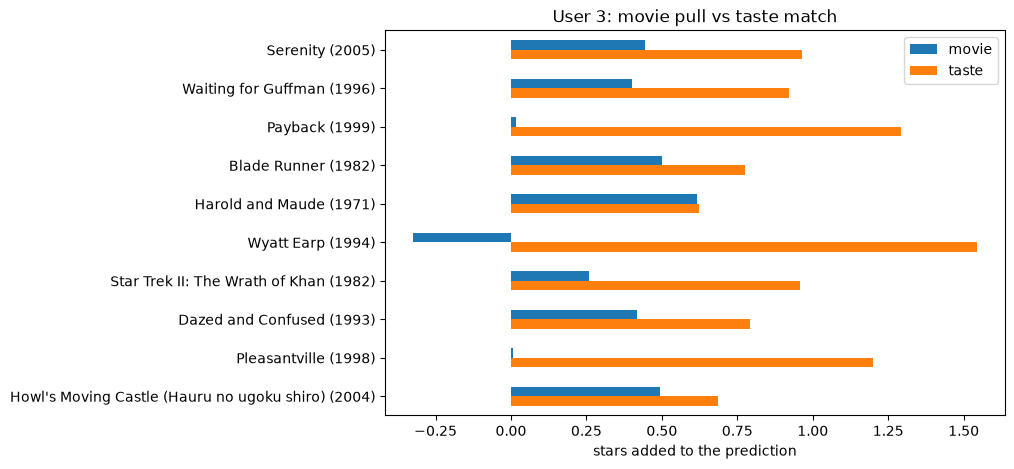

In [8]:
parts = pd.DataFrame(
    [score_parts(model, USER_ID, m) for _, m, _ in picks],
    index=[title_of[movie_id] for movie_id, _, _ in picks],
)

ax = parts[["movie", "taste"]].plot.barh(figsize=(8, 5))
ax.invert_yaxis()
ax.set_xlabel("stars added to the prediction")
ax.set_title(f"User {USER_ID}: movie pull vs taste match")
plt.show()

## 5. Do the two methods agree?

In [9]:
both = set(content["title"]) & set(mf["title"])
print("movies in both top 10 lists:", sorted(both) if both else "none")

movies in both top 10 lists: ['Blade Runner (1982)']
